/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando el modelo...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9246 - loss: 0.2604
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9691 - loss: 0.1069
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9789 - loss: 0.0702
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9847 - loss: 0.0515
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9888 - loss: 0.0382

Generando Matriz de Confusión...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


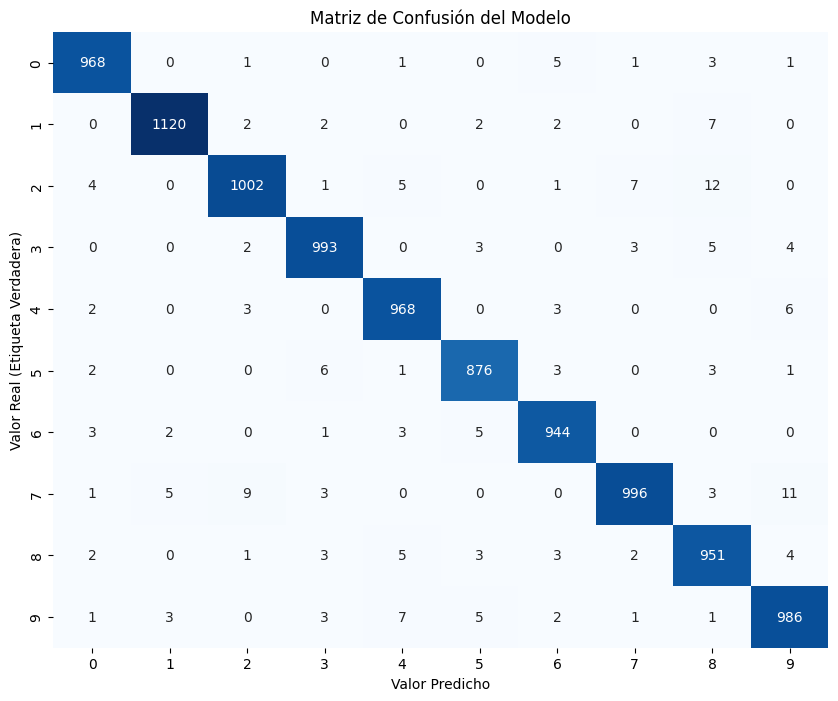


Sube una fotografía de un número del 0 al 9:


Saving tree flav.jpeg to tree flav.jpeg


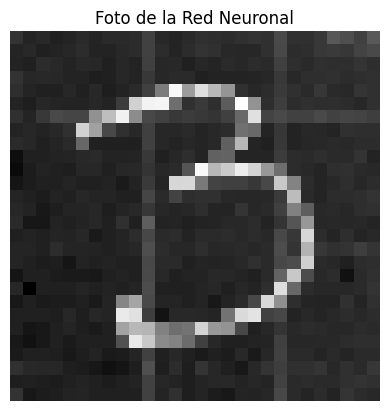

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
¡El modelo cree que tu número es el: 3!
Nivel de confianza: 40.23%


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 # Librería para procesar la imagen de tu fotografía
from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

# 1. Set de datos

(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

x_train = train_data.reshape((60000, 28 * 28)).astype('float32') / 255
x_test = test_data.reshape((10000, 28 * 28)).astype('float32') / 255

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

# 2. CREACIÓN Y ENTRENAMIENTO DEL MODELO

model = models.Sequential()
model.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Entrenando el modelo...")
model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)

# 3. MATRIZ DE CONFUSIÓN

print("\nGenerando Matriz de Confusión...")
# Hacemos predicciones sobre los datos de prueba
predicciones_test = model.predict(x_test)

# Convertimos las predicciones y etiquetas reales de One-Hot a números enteros (0-9)
y_pred_classes = np.argmax(predicciones_test, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculamos y graficamos la matriz
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Valor Real (Etiqueta Verdadera)')
plt.xlabel('Valor Predicho')
plt.show()

# 4. FUNCIÓN PARA PREDECIR TU FOTOGRAFÍA

def predecir_fotografia(ruta_imagen, modelo):
    # 1. Leer la imagen en escala de grises
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: No se encontró ninguna imagen en la ruta '{ruta_imagen}'")
        return

    # 2. Redimensionar la imagen a 28x28 píxeles (igual que MNIST)
    img_resized = cv2.resize(img, (28, 28))

    # 3. Invertir colores si es necesario (MNIST es número blanco, fondo negro)
    if np.mean(img_resized) > 127:
        img_resized = cv2.bitwise_not(img_resized)

    # Mostrar la imagen tal cual la verá la red neuronal
    plt.imshow(img_resized, cmap='gray')
    plt.title("Foto de la Red Neuronal")
    plt.axis('off')
    plt.show()

    # 4. Aplanar a 784 elementos y normalizar (dividir entre 255)
    img_reshaped = img_resized.reshape(1, 28 * 28).astype('float32') / 255

    # 5. Hacer la predicción
    prediccion = modelo.predict(img_reshaped)
    numero_predicho = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100

    print(f"¡El modelo cree que tu número es el: {numero_predicho}!")
    print(f"Nivel de confianza: {confianza:.2f}%")

# 5. CÓDIGO PARA SUBIR Y PROBAR TU IMAGEN

from google.colab import files
print("\nSube una fotografía de un número del 0 al 9:")
uploaded = files.upload()
for nombre_archivo in uploaded.keys():
    predecir_fotografia(nombre_archivo, model)